In [2]:
# installing dependencies

!pip install git+https://github.com/facebookresearch/fairchem.git@fairchem_core-2.0.0#subdirectory=packages/fairchem-core



  Cloning https://github.com/facebookresearch/fairchem.git (to revision fairchem_core-2.0.0) to /tmp/pip-req-build-exg952mq
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/fairchem.git /tmp/pip-req-build-exg952mq
  Running command git checkout -q 47b189b394ba90b9117ec68bb2074cf037984f02
  Resolved https://github.com/facebookresearch/fairchem.git to commit 47b189b394ba90b9117ec68bb2074cf037984f02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://gitlab.com/ase/ase.git (to revision 4a5e1f69979f9f5463a82001245e5471364adcf1) to /tmp/pip-install-mmnd0apd/ase_a7e0ca18f1e7428db372d145467698f4
  Running command git clone --filter=blob:none --quiet https://gitlab.com/ase/ase.git /tmp/pip-install-mmnd0apd/ase_a7e0ca18f1e7428db372d145467698f4
  Running command git rev-parse -q --verify 'sha^4a5e1f69979f9f5463a82001245e5471364adcf1'
  Running command git

In [3]:
import torch

torch_version = torch.__version__.split('+')[0]

!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
  -f https://data.pyg.org/whl/torch-{torch_version}+cpu.html

!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 546.1/546.1 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 783.0/783.0 kB 39.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.4/241.4 kB 14.1 MB/s eta 0:00:00


In [4]:
import torch_cluster
print("torch-cluster is installed ✅")

torch-cluster is installed ✅


In [6]:
# Standard library
import glob
from typing import Union

# Core data / math
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
from torch.utils.data import random_split

# PyTorch Geometric
from torch_geometric.data import Data
from torch_geometric.nn import SchNet
from torch_geometric.loader import DataLoader

# FairChem
from fairchem.core.datasets import AseDBDataset

In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.colab import drive
drive.mount('/content/drive')

In [175]:
# funcs for loading data
def find_files(directory: str = 'data', ext: str = '.aselmdb') -> list[str]:
    return glob.glob(f"{directory}/*{ext}")


def read_aselmdb(file_path: Union[str, list[str]] = './data'):
    """
    Reads one or more .aselmdb files.
    """
    if isinstance(file_path, str):
        file_path = [file_path]
    return MultiAseDBDataset(file_path)


def get_molecules_by_type(dataset, mol_type='biomolecules'):
    n = len(dataset)
    atoms = np.array([dataset.get_atoms(i) for i in range(n)], dtype=object)

    if mol_type is None:
        return atoms.reshape(-1, 1)

    mask = np.fromiter((atom.info.get('data_id') == mol_type for atom in atoms),\
        dtype=bool, count=n)
    return atoms[mask].reshape(-1, 1)


def process_file(file: Union[str, list[str]],
                molecule_type: str = 'biomolecules',
                max_molecules: int = 100):

    """
    Reads one or more .aselmdb files and returns filtered molecules.
    """

    # read in dataset from file names
    dataset = read_aselmdb(file)

    # total num of mols in entire dataset
    n_total = len(dataset)

    # define array and pre-allocate
    alloc_size = max_molecules if max_molecules is not None else n_total
    result = np.zeros((alloc_size, 1), dtype=object)

    count = 0 # for tracking

    for i in range(n_total):

        if count >= alloc_size:
            break

        atoms = dataset.get_atoms(i)

        if molecule_type is None or atoms.info.get('data_id') == molecule_type:
            result[count, 0] = atoms
            count += 1

    # cut any unfilled rows if fewer matches than alloc_size
    return result[:count]


class MultiAseDBDataset(AseDBDataset):
    """
    Extends AseDBDataset to support multiple .aselmdb files.
    """

    def __init__(self, file_paths: list[str]):
        super().__init__({"src": file_paths})

def get_max_atoms(dataset):
    length = np.zeros((len(dataset), 1))
    for idx, mol in enumerate(dataset):
        length[idx, 0] = int(len(mol[0].numbers))
    return int(np.max(length))

def mol_to_data(z, pos, y):
    z = torch.tensor(z, dtype=torch.long)
    pos = torch.tensor(pos, dtype=torch.float)
    y = torch.tensor(y, dtype=torch.float)

    return Data(z=z, pos=pos, y=y)

def get_data(dataset):

    max_atoms = get_max_atoms(dataset)
    N = len(dataset)

    # pre-allocate arrays
    Z = np.zeros((N, max_atoms), dtype=np.int32) # atomic numbers
    pos = np.zeros((N, max_atoms, 3), dtype=np.float32) # positions
    mask = np.zeros((N, max_atoms), dtype=bool) # for padding
    y = np.zeros(N, dtype=np.float32) # target: homo_lumo

    for i, atom in enumerate(dataset):

        n = len(atom[0])

        Z[i, :n] = atom[0].get_atomic_numbers() # get and store atomic nums
        pos[i, :n] = atom[0].get_positions() # get and store positions
        mask[i, :n] = 1 # gets rid of padding /1 = real atom
        homo_lumo_gap = atom[0].info["homo_lumo_gap"]
        if isinstance(homo_lumo_gap, (list, tuple, np.ndarray)):
            homo_lumo_gap = np.mean(homo_lumo_gap)

        y[i] = homo_lumo_gap # get and store target

    result = [mol_to_data(Z[i][mask[i]], pos[i][mask[i]], y[i]) for i in range(len(Z))]
    print(f"Processed {len(result)} atoms")
    return result


def split_data(dataset, train_size_pct: float):

    train_size = int(train_size_pct * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    return train_dataset, val_dataset

In [211]:
class SchNetModel(torch.nn.Module):
    def __init__(self,
                 hidden_channels: int = 100,
                 num_filters: int = 100,
                 num_interactions: int = 5,
                 num_gaussians: int = 500,
                 cutoff: int = 20,
                 max_num_neighbors: int = 32,
                 readout: str = "mean"):
        super().__init__()

        #Create SchNet module with parameters
        self.schnet = SchNet(
            hidden_channels = hidden_channels,
            num_filters = num_filters,
            num_interactions = num_interactions,
            num_gaussians = num_gaussians,
            cutoff = cutoff,
            max_num_neighbors = max_num_neighbors,
            readout = readout
        )

    #Forward step for model
    def forward(self, data):
        out = self.schnet(data.z, data.pos, batch=data.batch)
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bio_model = SchNetModel().to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=1e-4)
loss_fn = torch.nn.L1Loss()

def train(model: SchNetModel, train_data: list):
    model.train()
    total_loss = 0

    for data in train_data:
        data = data.to(device)

        optimizer.zero_grad()
        pred = model(data)
        loss = loss_fn(pred, data.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_data)

In [212]:
@torch.no_grad()
def evaluate(model: SchNetModel, val_data: list):
    model.eval()
    total_loss = 0

    for data in val_data:
        data = data.to(device)
        pred = model(data)

        loss = loss_fn(pred, data.y)
        total_loss += loss.item()

    return total_loss / len(val_data)

@torch.no_grad()
def test(model: SchNetModel, test_data: list):
    model.eval()

    total_mae = 0
    total_mse = 0
    total_samples = 0

    for data in test_data:
        data = data.to(device)

        pred = model(data)
        target = data.y.view(-1, 1)

        mae = torch.abs(pred - target).sum()
        mse = ((pred - target) ** 2).sum()

        total_mae += mae.item()
        total_mse += mse.item()
        total_samples += target.size(0)

    mean_mae = total_mae / total_samples
    rmse = (total_mse / total_samples) ** 0.5

    return mean_mae, rmse

In [213]:
# -------------- SET UP TRAINING DATASET ---------------
# given the local dataset path, loads the first .aselmdb file
dataset_path = '/content/drive/MyDrive/train_4M/data0000.aselmdb'
# dataset = AseDBDataset({"src": dataset_path})
files_list = dataset_path
dataset = process_file(files_list, molecule_type = 'biomolecules', max_molecules = 200)

# convert to torch
torch_data = get_data(dataset)
train_dataset, val_dataset = split_data(torch_data, 0.8)

# load
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

Processed 200 atoms


In [214]:
# ------------ RUN MODEL ------------------
epochs = 50
train_losses = np.zeros(epochs)
val_losses = np.zeros(epochs)

for epoch in range(50):
    train_loss = train(bio_model, train_loader)
    val_loss = evaluate(bio_model, val_loader)

    train_losses[epoch] = train_loss
    val_losses[epoch] = val_loss

    print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 7.6355 | Val Loss: 7.3502
Epoch 002 | Train Loss: 6.9699 | Val Loss: 6.6373
Epoch 003 | Train Loss: 6.2320 | Val Loss: 5.7792
Epoch 004 | Train Loss: 5.3117 | Val Loss: 4.6532
Epoch 005 | Train Loss: 4.1185 | Val Loss: 3.1110
Epoch 006 | Train Loss: 2.8106 | Val Loss: 1.9350
Epoch 007 | Train Loss: 2.5368 | Val Loss: 2.2048
Epoch 008 | Train Loss: 2.5885 | Val Loss: 1.8887
Epoch 009 | Train Loss: 2.3119 | Val Loss: 1.7521
Epoch 010 | Train Loss: 2.2616 | Val Loss: 1.7643
Epoch 011 | Train Loss: 2.2148 | Val Loss: 1.6413
Epoch 012 | Train Loss: 2.1017 | Val Loss: 1.5568
Epoch 013 | Train Loss: 2.0550 | Val Loss: 1.5184
Epoch 014 | Train Loss: 2.0194 | Val Loss: 1.4614
Epoch 015 | Train Loss: 1.9820 | Val Loss: 1.4172
Epoch 016 | Train Loss: 1.9525 | Val Loss: 1.3740
Epoch 017 | Train Loss: 1.9047 | Val Loss: 1.3355
Epoch 018 | Train Loss: 1.8827 | Val Loss: 1.3062
Epoch 019 | Train Loss: 1.8338 | Val Loss: 1.2773
Epoch 020 | Train Loss: 1.8299 | Val Loss: 1.2607


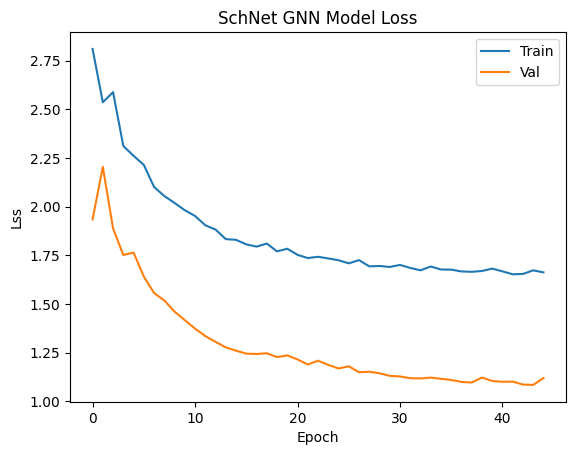

In [215]:
plt.plot(train_losses[5:])
plt.plot(val_losses[5:])
plt.title("SchNet GNN Model Loss")
plt.ylabel('Lss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

In [216]:
# --------------- SET UP TEST SET ---------------------
# given the local dataset path, loads the first .aselmdb file
dataset_path = '/content/drive/MyDrive/train_4M/data0001.aselmdb'
test_files_list = dataset_path
test_dataset = process_file(test_files_list, molecule_type = 'biomolecules', max_molecules = 200)

# convert to torch
test_torch_data = get_data(test_dataset)

# load
test_loader = DataLoader(test_torch_data, batch_size=32, shuffle=False)

Processed 200 atoms


In [217]:
# --------------- EVALUATE TEST SET -------------------
mae, rmse = test(bio_model, test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  1.3622
Test RMSE: 1.8775
